---
execute:
  skip: true
---

# 👁️‍🗨️ From Visualization to Calculation: Applying the Cost of Carry Model ⚖️

<br>


<div style="display: flex; flex-wrap: wrap; align-items: center; gap: 15px; margin-bottom: 25px; padding-bottom: 15px; border-bottom: 1px solid #eaeaea;">
  
  <a href="https://colab.research.google.com/github/PatrickJHess/Volume-Three-Chapter-One/blob/master/colab/Colab_Calculating_And_Graphing_The_Term_Structure_Of_Interest_Rates.ipynb" target="_blank" style="display: flex; align-items: center;">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="height: 28px; margin: 0;">
  </a>

  <a href="https://mybinder.org/v2/gh/PatrickJHess/Volume-Three-Chapter-One/master?urlpath=lab/tree/notebooks/Calculating_And_Graphing_The_Term_Structure_Of_Interest_Rates.ipynb" target="_blank" style="background-color: #f5a252; color: white; padding: 0 12px; text-decoration: none; font-weight: bold; border-radius: 4px; font-family: sans-serif; display: flex; align-items: center; font-size: 0.9em; height: 28px; box-sizing: border-box;">
    <span style="margin-right: 6px; font-size: 1.1em;">🚀</span> Launch Live in Binder
  </a>

  <a href="https://patrickjhess.github.io/Volume-Three-Chapter-One/" style="background-color: #f1f3f4; color: #3c4043; border: 1px solid #dadce0; padding: 0 12px; text-decoration: none; font-weight: bold; border-radius: 4px; font-family: sans-serif; display: flex; align-items: center; font-size: 0.9em; height: 28px; box-sizing: border-box;">
    <span style="margin-right: 6px; font-size: 1.1em;">⬅️</span> Return to Main Book
  </a>

</div>

In the previous notebook, we looked at the historical basis of S&P futures, crude oil, and corn from 30,000 feet. The visual contrast was clear. But looking at graphs is the easy part. The underlying concept makes intuitive sense; now it's time to get some dirt under our fingernails and actually build the machinery.

Let's step back for a moment and imagine an agreement to buy and sell a single share of stock at a future date—not a standardized futures contract, but a simple forward contract. Because both the buyer and seller have the option to just transact today, the forward contract must be at least as economically attractive as buying or selling on the spot market.

If the stock doesn't pay any dividends before the forward agreement expires, the seller receives no benefit from owning the stock beforehand, and the buyer doesn't suffer the loss of missing future dividends. Because the payment is delayed, the forward contract is effectively a financing agreement. The forward price has to compensate the seller for the interest they could have earned if they had sold today and banked the cash. Therefore, the forward price equals the stock price grossed up by the interest rate.

$$\text{Forward  Price}_{t,T} = \text{Stock Price}_t\times (1 +i_{t,T})$$

Where $t$ is the current period and the expiration is $T$. The interest rate for the period is $i_{t,T}$


Any dividends paid during the contract benefit the seller at the expense of the buyer. To keep the trade fair, the forward price has to be decreased by their future value at the time the contract expires.

$$\text{Forward Price}_{t,T} = \text{Stock Price}_t\times (1 +i_{t,T})-\text{FV}(\text{DIV}_{t,T})$$

Where $\text{FV}(\text{DIV}_{t,T})$ is the future value of any dividends paid between $t$ and $T$.


Let's pivot to a futures contract. Absent the dividends, the buyer (the long position) gets the benefit of owning the stock without putting up money for the period. The seller (the short position), assuming they already own the underlying stock, has converted the risky stock position into a safe asset.

Here we have identified the cost of carry cited in the previous notebook. We presented that formula as:

$$F= S + \text{Storage} - \text{Convenience or Dividend Yield} + \text{Interest}$$

Storage and Dividend Yield are well-understood mechanics; not so much for Convenience Yield (we briefly illustrated it with crude oil). Because it forces us to deal with precise moving parts, the September 2026 S&P 500 E-Mini contract is the perfect sandbox for illustrating the intricacies of real-world pricing.  

For an equity index we'll assume that:

* **The cost of storage:** is zero.  
* **Dividend yield:** is greater than or equal to zero.  
* **Convenience yield:** is zero.  
* **Interest:** is greater than or equal to the applicable SOFR rate.

On paper, this is just simple algebra. In practice? Pinning down the exact timing of dividends, matching the calendar days, and perfectly aligning the interest rate is a logistical headache. Ultimately, modeling this out reveals a persistent gap between the theoretical SOFR rate and the actual implied repo rate traded by the market. Arbitrage assumes a frictionless world—a limiting case in theory, and a moving target in reality.

Prepare yourself to encounter the messy details!

### 🤔 Bridging Theory & Practice: The Real Mechanics of Index Arbitrage

In a finance textbook, the fair value of a futures contract is elegantly defined by the continuous cost-of-carry model:

$$F = S \cdot e^{(r-y)t}$$

Where $r$ is the risk-free rate and $y$ is the continuous dividend yield. But this formula is largely a theoretical convenience that waves its hands at reality. It assumes dividends are paid out in a smooth, continuous stream—ignoring the lumpy, discrete reality of actual corporate dividend dates and cash flows.

More importantly, this frictionless equation implies that whenever $F$ deviates even slightly from this theoretical value, an arbitrageur can seamlessly step in and capture a riskless profit.

*But what does an arbitrageur actually have to do in the real world to capture that spread?*

<details>
<summary><strong>A.) If the Future is Priced Too High (F > Fair Value)</strong></summary>

* **The Trade:** Short the futures and go **long cash**.
* **The Mechanics:** To buy the underlying 500 stocks, the arbitrageur cannot simply fund the trade at the theoretical risk-free rate ($r$). They must physically borrow capital from a prime broker—often at a premium over $r$—and cross the bid-ask spread to purchase 500 individual equities in the open market.

</details>

<details>
<summary><strong>B.) If the Future is Priced Too Low (F < Fair Value)</strong></summary>

* **The Trade:** Go long the futures and go **short cash**.
* **The Mechanics:** his side of the trade is much harder. To short the cash index, the arbitrageur must physically locate and borrow shares for all 500 companies (some of which may be restricted or "hard-to-borrow"). By shorting the cash and investing the proceeds, the short leg effectively pays out the realized risk premium—though this market risk is neutralized by the long futures position. What isn't neutralized are the operational frictions: the arbitrageur is stuck paying the cost of borrowing the shares, crossing 500 bid-ask spreads, and covering the short dividends. An unavoidable wedge between what presents and what is possible.

</details>

---
> **🚨 The No-Arbitrage "Band"**
>
> The cost of carry equation is not static! Financial markets, like physical commodities, require infrastructure: crude oil arbitrage relies on physical pipelines and storage tanks; corn relies on barges and grain elevators. Index arbitrage relies on **financial plumbing**—prime brokerages, repo desks, and stock loan departments.
>
> But financial plumbing isn't built of steel—it’s built of balance sheets. Its capacity is entirely dependent on the market's risk tolerance. In a risk-on environment, the pipes are wide open and arbitrage bands are tight. But the moment sentiment flips risk-off, banks pull credit, borrow contracts, and the infrastructure constricts. Why not stand up more bandwidth? Not instantaneously, and not without cost—arbitrage bands dramatically widen right when the theoretical mispricings are largest.

## 🛠️ What We Are Doing Here: Illustrating the Mechanics

To demonstrate the messy reality of these arbitrage mechanics, we are going to build a model using real-world market data. Before we start pulling prices, we need to establish the ground rules for this notebook: we are illustrating, not verifying.

Simplifying assumptions have been made to compensate for unattainable professional data. For example, we use implied forward SOFR rates from the futures contract to calculate the future value of dividends. But the most critical assumption is that actual dividends are the same as expected dividends.

> In the real world, you cannot know the exact payout of a future dividend with 100% certainty. Institutional arbitrageurs rely on expensive, proprietary data feeds (from providers like Bloomberg or IHS Markit) to model their forward dividend expectations—sources that are unavailable to us.

What we present here is an illustration of the required mathematical and logistical infrastructure. The point is demonstration, and raising the question about dynamic arbitrage bands.

<details>
<summary style='font-size:15px'><b>How to use this page: Run, Copy, & Download</b></summary>

<ul>
  <li><b>⏻ Run code right here:</b> Click the <b>Power Button</b> icon at the top of the screen to activate <b>Live Code</b>.</li>
  <li><b>📋 Copy code:</b> Hover over any code block and click the <b>Clipboard icon</b> in the top-right corner.</li>
  <li><b>📥 Download this file:</b> Click the <b>Download icon</b> (downward arrow) at the top right of the screen to save this exact notebook to your computer.</li>

</details>

<details>
<summary><b style="font-size:1.2em; color: #1976d2;">⚡🔌 Notebook Setup: Why the "Try/Except" Imports?</b></summary>
<br>

<p><b>The Goal:</b><br>
To ensure this notebook runs perfectly whether you are using <b>Google Colab</b>, a local <b>Jupyter instance</b>, or a remote server without you having to manually install software.</p>

<ul>
  <li><b>External Libraries:</b> NumPy and Pandas are the "heavy hitters" for data. They aren't always installed by default.</li>
  <li><b>The <code>try/except</code> Logic:</b> This is a safety net.
    <ol>
      <li>We <b>try</b> to import the library.</li>
      <li>If it fails (because it's not installed), the <b>except</b> block triggers a <code>%pip install</code> to download it automatically.</li>
    </ol>
  </li>
  <li><b>Aliasing (<code>as np</code>):</b> We rename <code>numpy</code> to <code>np</code> to save keystrokes. In professional finance code, <code>np</code> and <code>pd</code> are the universal shorthand.</li>
</ul>
</details>

## 🛠️ Preparing the Notebook


<details>
<summary><b>👉 Click to Expand: 📦 Importing Libraries, Modules, and Functions</b></summary>
As a best practice, we always begin by importing our necessary dependencies in the very first code cell. Notice how lightweight our imports are here: just the built-in `request` module and the `pandas` and `numpy` libraries. ✨

This simplicity is a direct result of using the `financial_quant` package, which handles the heavy lifting behind the scenes. 🏗️ By keeping complicated setup details out of sight, we ensure the spotlight remains focused exactly where it belongs—on the core analysis. 🎯

```python
try:
    import numpy as np
except:
    %pip install numpy
    import numpy as np
try:
    import pandas as pd
except:
    %pip install pandas
    import pandas as pd
```
**👀 Keep an eye out**: As we progress, pay attention to how the `financial_quant` package is imported as `fq`, and how every reference to its functions begins with fq.. 💡 This follows the exact same standard practice as NumPy (np) and Pandas (pd).
</details>

In [ ]:
try:
    import numpy as np
except:
    %pip install numpy
    import numpy as np
try:
    import pandas as pd
except:
    %pip install pandas
    import pandas as pd

## 📦 Getting Functions from financial_quant package

<details>
<summary><b style="font-size:1.2em; color: #1976d2; cursor: pointer;"><span style="font-size: 1.4em;">⚡🔌</span> Professional Packaging: How GitHub Installations Work</b></summary>
<br>
<p><b>The Logic:</b><br>
Usually, Python looks for modules as <code>.py</code> files on your hard drive. Here, we are "tricking" Python into treating a string of text from a URL as a live library.</p>

<p><b>The Workflow:</b></p>
<ol>
<li><b>Fetch & Build:</b> The <code>%pip install git+https://...</code> command tells your Jupyter environment to clone the repository from GitHub and install the <code>financial_quant</code> package directly into your system's site-packages directory.</li>
<li><b>Import:</b> <code>import financial_quant as fq</code> loads the package into your notebook's memory and assigns it the quick alias <code>fq</code>.</li>
<li><b>Routing:</b> Behind the scenes, a special file called <code>__init__.py</code> ats as the package's "front door." It automatically gathers complex tools from deeply nested folders (like our fixed-income models and chart visualizers) and serves them up directly to the surface.</li>
<li><b>Execute:</b> You don't have to worry about where the files live. You just type <code>fq.one_y_axis() or fq.calc_ytm()</code>, and Python immediately knows where to route the request.</li>
</ol>

<p><b>Why do this?</b><br>
This is exactly how professional software engineering teams manage and distribute code. It keeps your notebooks incredibly clean, ensures everyone is using the exact same version of the math models, and guarantees your code is 100% portable to any cloud environment</p>
</details>

In [ ]:
# Use Python's built-in urllib to fetch the remote setup script
import urllib.request

# Download, decode, and execute the updater script directly from GitHub
updater_url = "https://raw.githubusercontent.com/PatrickJHess/quant_repo/master/fq_updater.py"
exec(urllib.request.urlopen(updater_url).read().decode('utf-8'))

# Run the installer/updater function and alias the package as 'fq'
fq = import_financial_quant()

☁️ Cloud environment detected. Installing fresh from GitHub...
✅ Installation complete!
Mounted at /content/drive
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 🏦 The Baseline: SOFR and the NY Fed

To measure our financing advantage, we need a baseline interest rate. For modern financial markets, that baseline is **SOFR** (the Secured Overnight Financing Rate).

Unlike older legacy rates (like LIBOR) that relied on subjective bank estimates, SOFR is a hard, transaction-based rate calculated daily by the New York Fed. It represents the actual cost of borrowing cash overnight collateralized by Treasury securities. Because it applies to "safe" lending, it tends to be pretty sticky, but it does fluctuate from day to day.

> 🔗 **Want to go down the rabbit hole?** *Read the [NY Fed's official SOFR methodology here](https://www.newyorkfed.org/markets/reference-rates/sofr).*


---

### 🏁 Checkpoint
Before we look at the math, let's review what we know and assume:
1. We know we need to account for real-world frictions (The Arbitrage Band).
2. We know we are illustrating mechanics using actual historical dividends as our proxy.
3. We assume our baseline financing rate is SOFR.

Next we'll isolate the exact interest rate for calculating the future value of dividends. Let's look at the algebra.

## 📐 Isolating the Financing Advantage

Before we can measure the frictions and prime broker premiums that create our no-arbitrage band, we need a clean baseline. In modern markets, the baseline for the theoretical risk-free rate ($r$) is SOFR—the Secured Overnight Financing Rate that applies to fully collateralized lending.

Although SOFR tends to be sticky, it does fluctuate day to day. To lock in our baseline for a forward-looking trade, we'll use the three-month SOFR futures contract highlighted in Chapter One (Data Infrastructure to Market Mechanics).

>⚠️ Heads up: As we just established, the actual rate of finance for an S&P 500 arbitrageur will differ from SOFR. The actual funding rate baked into the equities futures contract is called the implied repo rate. We must calculate the "clean" SOFR baseline first so that we can compare it against the S&P 500's implied repo rate to measure the exact size of the real-world friction.

#### What SOFR rate do we need?
In order to calculate the future value at any payment date $t$, we need the forward rate from $t$ until the expiration date $T$. These calculations are extracted from the 3-Month SOFR futures contract with an expiration date matching the S&P 500 E-mini contract.

>⚠️ Heads up: The 3-Month SOFR contract month is actually the quarter before the expiration month. A future chapter of this Volume offers a more detailed description of why, but for now, it's sufficient just to be aware of the plumbing quirk.

Before the contract reference period (roughly three months before the final day of trading), the forward rate for the accrued SOFR equals 100 less the settlement price. We'll account for this in our code with a Pandas mask—keep an eye out for this as a practical example of how masks are used.


**The Math Problem:** Once we are inside that 3-month reference window, the futures settlement price becomes a blend. It embeds the history of the SOFR rate that has already happened, plus the forward rate for the days remaining.

For our calculations, we only want the future. Therefore, we have to strip out the historical rates. We can infer the necessary adjustment by noting that the total rate is just the historical rate multiplied by the forward rate.

Imagine a 90-day contract settling at 5%. If we are 30 days into the contract and the actual rate has been 4%, the market must be pricing the remaining 60 days at 5.5% to make the math work:

$$1.008969=\large\frac{1.05^{\frac{90}{360}}}{1.04^{\frac{30}{360}}}$$

$$1.05504 =  1.008969^{\frac{360}{60}}$$

The same idea is applied to the forward for June SOFR contract:

$$1 + R^{futures}_{t+n} \times \frac{T-t}{360} = \left(1 + R^{actual}_{t+n} \times \frac{n}{360}\right) \times \left(1 + R^{forward}_{t+n} \times \frac{T-t-n}{360}\right)$$

Where:

*  $t$ is the start of the calculation period,
*  $T$ is the end of the calculation period,
*  $t+n$ is the current time,
*  $R^{futures}_{t+n}$ is the accrued SOFR implied by the futures price,
*  $R^{actual}_{t+n}$ is the realized accrued SOFR between $t$ and $t+n$,
*  $R^{forward}_{t+n}$ is the forward SOFR rate implied by the futures at $t+n$.

Life is made easier by calculating the realized accrued SOFR with the ratio of the SOFR Index at $t+n$ and $t$:

$$1 + R^{actual}_{t+n} \times \frac{n}{360} = \frac{\text{SOFR Index}_{t+n}}{\text{SOFR Index}_{t}}$$

By substituting this index ratio into our first equation, we can rearrange the algebra to solve purely for the forward SOFR rate:

$$R^{forward}_{t+n} = \left( \left(1 + R^{futures}_{t+n} \times \frac{T-t}{360}\right) \times \frac{\text{SOFR Index}_{t}}{\text{SOFR Index}_{t+n}} - 1 \right) \times \frac{360}{T-t-n}$$

We will use this exact formula in our code to infer forward rates from the SOFR futures contract for any day in the reference period ($n\geq0$). Before the reference period and on the first day ($n\leq0$), the forward rate is the rate implied by the futures contracts:

$$R^{forward}_{t+n} = \frac{100 - \text{Settlement}_{t+n}}{100}$$

<details>
<summary>🕵️‍♂️ <b>Interest On Variation Margin: A Sneaky Effect</b></summary>
<br>

<blockquote>

When we think about futures, our focus is typically on the asset that the futures are written on. For example, the S&P 500 or Crude Oil are volatile markets, and worrying about interest on margin seems like a tempest in a teapot.

But what about the SOFR contract? Here, futures prices are directly related to changes in interest rates. What happens when rates go up?

* **The Short** benefits and is able to invest their daily margin gains at a higher interest rate.
* **The Long** must finance their losses by borrowing at a higher rate (or forgoing higher earnings).

When rates go down?

* **The Short** loses but is able to finance the loss at a lower interest rate (forgoing less interest).
* **The Long** benefits but the gains are invested at a lower interest rate.

You may recognize this as **convexity**—a concept discussed in the chapter <a href="https://patrickjhess.github.io/Volume-Four-Chapter-Four/"><i>Interest Rate Risk: From Static Metrics to Dynamic Simulation</i></a>.

Because of this daily settlement dynamic, the SOFR contract isn't "even-steven" relative to the cash market. To correct this unevenness, the futures price has to be <b>lower</b> than that implied by the cash market. In other words, the implied interest rate has to be <i>higher</i>.

<b>How important is this effect?</b>

It depends upon the horizon. Here, we are going to look at S&P 500 contracts that expire within a quarter. For these short horizons, the effect can be safely ignored and is well within the limits of other approximations. In future chapters, we'll take a more detailed look at SOFR and relate it to swaps—where this attention will be warranted.

</blockquote>

</details>

---
>🛑 Note: You do not need to memorize this algebraic derivation! We are showing you the engine under the hood so you know it isn't magic. Your job is to understand the output: we are simply extracting the future interest rate from a blended average.

### 💻 **From Theory to Code:** 
Let's translate this formula into a reusable, vectorized Python function. By passing our dataset directly into the engine, we can instantly calculate the stripped forward financing rate for every single day in our timeline.

**Handling Reference Period Transitions**

To handle the transition into the reference period, we use two boolean masks (base_rate_mask and implied_rate_mask). These masks ensure the data is routed correctly, applying the basic closing futures price before the reference period begins, and seamlessly switching to the complex implied forward rate calculation (incorporating the SOFR Index) once inside the reference period.


:::{dropdown}📝 An Example Of How Pandas Boolean Masks Work
<br>
In Pandas, a boolean mask is simply a series of <code>True</code> and <code>False</code> values used to filter rows. Instead of writing slow <code>for</code> loops, masks vectorize code. In our application, we apply complex calculations to specific parts of the SOFR Index and futures data. Pandas masks define the range of calculations.

Below is a simple example you can try on your own.

```python
import pandas as pd
df = pd.DataFrame({'price': [100, 102, 105]}, index=['2026-09-15', '2026-09-16', '2026-09-17'])

# 1. Create the mask (Returns True if date is after 09-15)
implied_rate_mask = df.index > '2026-09-15'
# Conceptually: [False, True, True]

# 2. Apply a calculation ONLY to the 'True' rows using .loc
df.loc[implied_rate_mask, 'status'] = 'Active'
#Results:
#             status
# 2026-09-15  NaN
# 2026-09-16  Active
# 2026-09-17  Active
```
:::


**A Mask to Handle Division by Zero**

```
valid_calc_mask = implied_rate_mask & (days_remaining >= 1).
```
This acts as a mathematical safety valve. On the final days of the contract (September 2026), the reference period converges on expiration, and the remaining days reach zero. By chaining our active date mask with this greater-than-zero check, we ensure pandas only attempts the final implied rate calculation—specifically the (360 / days_remaining) component—where it is mathematically valid.

In [ ]:
def forward_curve(df,start,end):

  # [Equation] R^{forward}_t = (100 - Settlement_t) / 100
  df['Accrued'] = (100-df['settlement_price'])/100

  # [Variables] T - t: Total days in the calculation period
  total_days=(pd.Timestamp(end)-pd.Timestamp(start)).days

  # Align future and SOFR data
  df_forward=pd.concat([df['Accrued'],sofr_index],axis=1,join='inner')
  df_forward.columns=['Accrued','SOFR_Index']

  # Calculate implied forward rates
  # 1. Safely calculate T-t-n (days remaining) as a numpy array
  days_remaining = (pd.Timestamp(end) - df_forward.index).days

  # 2. Define the rate calculation masks
  # [Theory] See "Handling Reference Period Transitions" -routing data for n <= 0 and n > 0
  base_rate_mask = df_forward.index <= pd.Timestamp(start)
  implied_rate_mask = df_forward.index > pd.Timestamp(start)

  # 3. Assign the pre-reference period rates (base rate)
  # [Theory] On or before Day 0, the forward rate is the implied futures rate.
  # (Note: At exactly Day 0, the complex formula mathematically collapses to this same result).
  df_forward.loc[base_rate_mask, 'SOFR_Index_Ratio'] = 1
  df_forward.loc[base_rate_mask, 'Forward Rate'] = df_forward['Accrued']

  # 4. Combine 'refer_period' with the 'days_remaining >= 1' check to prevent division by zero
  # # [Theory] See "A Mask to Handle Division by Zero" text block
  valid_calc_mask = implied_rate_mask & (days_remaining >= 1)

  # 5. Apply your complex ratio math cleanly using the combined mask
  # [Formula] Calculates the (SOFR Index_t / SOFR Index_t+n) fraction
  df_forward.loc[implied_rate_mask,'SOFR_Index_Ratio']=df_forward['SOFR_Index'][start]/df_forward['SOFR_Index']

  # [Equation] Rearranged algebra for R^{forward}_{t+n}:
  # R_forward = ((1 + R_futures * (T-t)/360) * Index_Ratio - 1) * (360 / (T-t-n))
  df_forward.loc[valid_calc_mask, 'Forward Rate'] = (
      (
          (1 + df_forward.loc[valid_calc_mask, 'Accrued'] * total_days / 360)
          * df_forward.loc[valid_calc_mask, 'SOFR_Index_Ratio'] - 1
      )
      * (360 / days_remaining[valid_calc_mask])
  )

  return df_forward

## ⚖️ Comparing The Financial Gain Of The S&P 500 Contract To SOFR
Our experiment uses the September 2026 S&P 500 E-mini contract. The roll date is conventionally the second Thursday before the near-term contract's expiration. The June 2026 final settlement is at the opne on June 19, so our start date is **Thrusday, June 11, 2026**. The September 2026 final settlement is the open on September 18. Our final daily settlement price is **Thursday, September 17**.

The closing prices for the S&P 500 and the SOFR Index are accessed from **FRED**. The 3-month SOFR and S&P 500 futures contracts are pulled from **Massive**.

> 📌 **Taking Stock: Approximations & Dynamic Bands**
>
> As we prepare to evaluate the data, keep two key pedagogical takeaways in mind:
>
> 1. **We are illustrating, not backtesting:** We use actual realized dividends as a proxy for market expectations, and we intentionally ignore minor short-dated convexity and daily tailing effects.
> 2. **Arbitrage bands are dynamic, moving corridors:** Textbook models draw arbitrage as a single fair-value line. In practice, arbitrage bounds expand and contract continuously based on prime brokerage haircuts, short-locate fees, balance sheet costs, and prevailing market volatility.
>
> When inspecting the spread between our implied repo rate and SOFR, ask yourself: *Is a deviation an unexploited profit opportunity, or simply market prices trading within a breathing arbitrage band?*

## 🚰 Futures, the SOFR Index, SP 500 Total Returns Index, and Spot Prices: A Job For Our Data Pipelines

We will use three custom data pipelines—`FredReader`,`MASSIVEReader`, and `static_futures_data`--to pull the necessary data for this notebook. All three are included in the `financial_quant` package that we imported earlier as `fq`.

To divide and conquer the workload, we will instantiate two specific data objects:

* `fred_data`: Powered by `FredReader`, this fetches the underlying SOFR Index and S&P 500 Price.
*  `massive_data`: Powered by `MASSIVEReader`, this serves as our primary engine for downloading the daily futures contract data.
* `static_futures_data`: This module supplies the S&P 500 Dividend data.

In [ ]:
# Instantiate the data pipelines from the financial_quant package
fred_data = fq.FredReader()
massive_data = fq.MASSIVEReader(calls_per_minute=5)
static_futures_data=fq.static_futures_data

☁️ Colab environment detected. Attempting to mount Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Cache anchored at: /content/drive/MyDrive/FRED
✅ Key loaded seamlessly from Colab Secrets ('fred_key')
☁️ Colab environment detected. Attempting to mount Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Cache anchored at: /content/drive/MyDrive/MASSIVE_DATA
✅ Key loaded seamlessly from Colab Secrets ('massive_key')


### 🏗️ Assembling the Dataset
With our pipelines ready, we can now assemble our dataset. In the code below, we will:

1. **Set the Timeframe:** Define our calculation window from June 11, 2026, to the final settle date on September 17, 2026..

2. **Fetch the Raw Data:**
    * Use `fred_data` to pull the **S&P 500** cash price and the **SOFR Index**.
    * Use `massive_data` to pull the specific September 2026 and June 2026 futures contracts: **E-mini S&P 500 (ESU6)** and **3-Month SOFR (SR3M6)**.
    * Use `statiic_futures_data` to pull the **S&P 500** dividend data.


3. **Merge and Align:** Align the data series. This is a critical step, ensuring we only keep days where all data points are present across both platforms.

4. **Clean and Isolate:** Rename the raw data columns into intuitive labels (Spot, Futures, Forward SOFR) and lock them into a clean, independent dataframe called df_forward.

> **Pandas Pro-Tip:** Notice the `.copy()` at the very end of the code? This creates a brand new dataframe in memory, which safely prevents Pandas from throwing a pesky `SettingWithCopyWarning` when we add our calculation columns later!

## 📥 Three Data Sources



1.   **FRED:** Closing prices of the S&P 500 and the SOFR Index
2.   **MASSIVE**: June 2026 SOFR contract and September 2026 S&P 500 contract
3.   **Static Data**:S&P 500 dividend data between June 11 and September 19, 2026. This data represents the total amount of dividends that have gone ex-dividend in the quarter as of the index. Conveniently, this quarterly cycle resets on the final settlement date of the S&P 500 futures contract.

> 💡 **The Dirty Details: Ex-Dates vs. Pay Dates**

> In calculating the future value of dividends, we have to account for the difference between the ex-dates and payment dates. That window of time is typically between two and four weeks. To calculate the forward financing rate up to our S&P 500 expiration date, we use the June SOFR contract (SR3M6).

>But what about dividends paid after the contract expires? Rather than introducing a second SOFR contract (the September contract) to cover those few remaining weeks, we'll freeze the interest rate observed on the expiration date of the June contract. Those late dividends are discounted back to expiration at that constant rate. Because the time gap is short and SOFR is a low-volatility rate, the effect should be negligible. We will tackle the complexities of building continuous predictive forward curves in a later chapter when we model interest rate swaps with SOFR futures.

Let's fetch the data and peek at the `tail()` of each to ensure everything is wired up correctly.

In [ ]:
# 1. Set the Timeframe
# [Theory] t = June 11 (Roll date, 8 days prior)
# [Theory] T = Sept 17 (Final daily settle prior to Friday AM expiration)
start_date = '2026-06-11'
end_date = '2026-09-19'

# 2. Fetch the Raw Data
# FRED Data
# [Variables] SP500 closing price and SOFR Index
sp_500=fred_data.get_series(['SP500'],start_date=start_date,end_date=end_date)
sofr_index=fred_data.get_series(['SOFRINDEX'],start_date=start_date,end_date=end_date)

# MASSIVE Data
# [Variables] SR3M6 (for R^futures), ESU6 (for F)
df_sofr_jun = massive_data.get_futures_data('SR3M6', start_date, end_date)
df_sp500_sep = massive_data.get_futures_data('ESU6', start_date, end_date)

# Static Data
# FV(DIV_t,T)
dividend_data = static_futures_data('SP_Quarterly_Dividends')

# [Data Pipeline] Convert string index to DatetimeIndex to align dates across SOFR and Futures DataFrames
dividend_data.index = pd.to_datetime(dividend_data.index)

# 3. Confirm downloads
display(sp_500.tail())
display(sofr_index.tail())
display(df_sofr_jun.tail())
display(df_sp500_sep.tail())
display(dividend_data.tail())


☁️--- Processing SP500 ---
🕒 Metadata is fresh (2 days old).
 Skipping GitHub static repo check (Tier disabled).
☁️ Fetching fresh SP500 observations from API...
Success! Saved fresh Parquet data to /content/drive/MyDrive/FRED/SP500_fred.parquet.

☁️--- Processing SOFRINDEX ---
🕒 Metadata is fresh (2 days old).
 Skipping GitHub static repo check (Tier disabled).
☁️ Fetching fresh SOFRINDEX observations from API...
Success! Saved fresh Parquet data to /content/drive/MyDrive/FRED/SOFRINDEX_fred.parquet.
🚀 Fetching futures data for SR3M6 (1 day)...
🔍 Cache miss. Checking Static_Data_Repo for SR3M6_1_day_data.parquet...
🔗 Attempting remote fetch: https://raw.githubusercontent.com/PatrickJHess/Static_Data_Repo/main/massive/SR3M6_1_day_data.parquet
⚠️ Remote fetch failed: HTTP Error 404: Not Found
☁️ Downloading SR3M6 (1_day) via API from 2026-06-11 to 2026-09-18...
💾 Merged and saved SR3M6 to Parquet cache. (Total Coverage: 2026-06-11 to 2026-09-15)
🚀 Fetching futures data for ESU6 (1 day)

,SP500
DATE,
2026-09-14,7619.98
2026-09-15,7585.73
2026-09-16,7551.81
2026-09-17,7637.76
2026-09-18,7650.50


,SOFRINDEX
DATE,
2026-09-14,1.258714
2026-09-15,1.258841
2026-09-16,1.258968
2026-09-17,1.259095
2026-09-18,1.259229


,Symbol,session_end_date,open,high,low,close,transactions,volume,dollar_volume,settlement_price,last_fetched
window_start,,,,,,,,,,,
2026-09-09,SR3M6,2026-09-09,96.3525,96.3525,96.3500,96.3500,273,20509,1.976069e+06,96.3500,2026-09-28 10:35:57.277124
2026-09-10,SR3M6,2026-09-10,96.3525,96.3550,96.3500,96.3550,487,64492,6.213987e+06,96.3525,2026-09-28 10:35:57.277124
2026-09-11,SR3M6,2026-09-11,96.3525,96.3550,96.3525,96.3525,810,44620,4.299320e+06,96.3525,2026-09-28 10:35:57.277124
2026-09-14,SR3M6,2026-09-14,96.3550,96.3550,96.3525,96.3550,131,21178,2.040600e+06,96.3525,2026-09-28 10:35:57.277124
2026-09-15,SR3M6,2026-09-15,96.3550,96.3550,96.3525,96.3550,92,11152,1.074527e+06,96.3525,2026-09-28 10:35:57.277124


,Symbol,session_end_date,open,high,low,close,transactions,volume,dollar_volume,settlement_price,last_fetched
window_start,,,,,,,,,,,
2026-09-14,ESU6,2026-09-14,7609.25,7652.00,7593.75,7632.25,244638,737362,5.619569e+09,7625.00,2026-09-26 09:33:45.338076
2026-09-15,ESU6,2026-09-15,7631.00,7633.25,7576.75,7596.75,104999,258019,1.959686e+09,7589.25,2026-09-26 09:33:45.338076
2026-09-16,ESU6,2026-09-16,7596.50,7632.00,7509.25,7555.25,76456,158661,1.203558e+09,7556.50,2026-09-26 09:33:45.338076
2026-09-17,ESU6,2026-09-17,7612.50,7654.50,7509.25,7636.00,110799,234787,1.784938e+09,7640.00,2026-09-26 09:33:45.338076
2026-09-18,ESU6,2026-09-18,7637.00,7670.25,7625.25,7643.25,3731,7742,5.919386e+07,7657.35,2026-09-26 09:33:45.338076


,S&P 500 Dividend Points Index (Quarterly)
Date,
2026-09-17,20.62
2026-09-18,20.66
2026-09-21,0.64
2026-09-22,0.68
2026-09-23,0.74


## 🗓️ An Important Discrepancy

Notice here that the data for the June SOFR contract (SR3M6) ends on September 15. The S&P 500 contract and cash price end on September 18 (the settlement day), and the dividend data ends on September 23.

Even though our evaluation period ends on September 17, we need the final amount (the September 18 value) to account for the future value of the contract's dividends.

Because the SOFR contract ends on September 15, we need to pull it forward to account for the later pay dates. The next step assembles the data and uses the last observed forward rate value to discount those future dates.

## 🏗️ Assembling the Market Data
Now that we have fetched our raw ingredients, we need to process and combine them into a single, cohesive dataset.

First, we execute our `forward_curve` function. By passing in the June SOFR contract, we generate the daily implied forward rates ($R^{forward}_{t+n}$) that will serve as our interest rate leg up to the September expiration.But we need an adjustment for the missing days (September 17 and 18). We'll make this adjustment by copying the final row (our forward rate approximation) and appending it for those last two dates.

```
# Copy the data for September 15
last_row = df_forward.iloc[-1]
last_date = df_forward.index[-1]

# Add September 16, 17, and 18
next_date_1 = last_date + pd.Timedelta(days=1) # 2026-09-16
next_date_2 = last_date + pd.Timedelta(days=2) # 2026-09-17
next_date_3 = last_date + pd.Timedelta(days=3) # 2026-09-18

# Create a DataFrame from the new rows
new_rows = pd.DataFrame([last_row.values, last_row.values,last_row.values],
                        columns=df_forward.columns,
                        index=[next_date_1, next_date_2,next_date_3])

# A simple `concat` appends the rows
df_forward = pd.concat([df_forward, new_rows])
```

Next, we merge all five of our distinct data series into one DataFrame. Notice the use of `join='inner'`. It aligns our data when markets are not: e.g. equity and future markets are often open when banks and bond markets are closed. An inner join enforces strict timeline alignment, keeping only the days where we have a complete set of actionable closing prices across all markets. If a price is missing in one market, the day is dropped.

We rename the columns for clarity and isolate our core variables into a pristine DataFrame called `market_data`.

>💡 **Notice the Dividend Behavior**

>When you run the cell below, look closely at the Q_Dividends column in the final output. The S&P 500 Dividend Points Index tracks the accumulation of dividends for the quarter, and you will see it reset to zero right after the contract expiration.

In [ ]:
# 1. Calculate forward rates
# [Theory] Execute forward_curve to generate R^{forward}_{t+n} for the interest rate leg.
# [Equation] Calculates R^forward_{t+n} using the derived formula:
# R_forward = ((1 + R_futures * (T-t)/360) * (Index_t / Index_t+n) - 1) * (360 / (T-t-n))
df_forward = forward_curve(df_sofr_jun,start_date,end_date)

# Copy the data for September 15
last_row = df_forward.iloc[-1]
last_date = df_forward.index[-1]

# Add September 16, 17, and 18
next_date_1 = last_date + pd.Timedelta(days=1) # 2026-09-16
next_date_2 = last_date + pd.Timedelta(days=2) # 2026-09-17
next_date_3 = last_date + pd.Timedelta(days=3) # 2026-09-18

# Create a DataFrame from the new rows
new_rows = pd.DataFrame([last_row.values, last_row.values,last_row.values],
                        columns=df_forward.columns,
                        index=[next_date_1, next_date_2,next_date_3])

# A simple `concat` appends the rows
df_forward = pd.concat([df_forward, new_rows])

# 2. Merge and Align
# [Theory] Frictionless market alignment: join='inner' aligns data when markets are not.
# It enforces strict timeline alignment (e.g., dropping mismatched bank/bond vs. equity holidays),
# keeping only days where we have actionable closing prices across all markets.
df = pd.concat([sp_500, sofr_index,df_forward,df_sp500_sep,dividend_data],
               axis=1, join='inner').dropna()


# 3. Clean and Isolate
# [Theory] Rename columns for clarity and isolate core variables into a pristine DataFrame.
df.rename(columns={'SP500': 'Spot',
                   'S&P 500 Dividend Points Index (Quarterly)':'Q_Dividends',
                   'settlement_price':'Futures'},
           inplace=True)

# [Pandas Pro-Tip] Isolate our variables into a clean DataFrame using .copy()
# This explicitly prevents SettingWithCopyWarnings when calculating basis later.
market_data = df[['Futures', 'Spot', 'Forward Rate','Q_Dividends']].copy()

# [Theory] Document that dividends are reset to zero at the contract expiration.
display(market_data.head(7))
display(market_data.tail())

,Futures,Spot,Forward Rate,Q_Dividends
2026-06-11,7458.50,7394.30,0.036650,18.19
2026-06-12,7497.50,7431.46,0.036628,18.55
2026-06-15,7626.50,7554.29,0.036673,20.29
2026-06-16,7587.25,7511.35,0.036666,20.52
2026-06-17,7492.75,7420.10,0.037012,20.62
2026-06-18,7570.75,7500.58,0.037177,20.72
2026-06-23,7437.50,7365.46,0.037215,0.50


,Futures,Spot,Forward Rate,Q_Dividends
2026-09-14,7625.00,7619.98,0.036030,18.84
2026-09-15,7589.25,7585.73,0.035984,20.11
2026-09-16,7556.50,7551.81,0.035984,20.40
2026-09-17,7640.00,7637.76,0.035984,20.62
2026-09-18,7657.35,7650.50,0.035984,20.66


## 🧮 Extracting Discrete Daily Cash Flows

To calculate the future value of the dividends, we need to know exactly how much cash goes ex on each specific day. The `Q_Dividends` column gives us a *cumulative* running total for the quarter.

To find the discrete daily dividend, we simply subtract yesterday's total from today's total using the Pandas `.diff()` function.

But there is a catch: **the quarterly reset**.

On the first day after the June S&P contract expires (June 23, 2026), the cumulative index resets from a large number back down to zero. If we apply a standard `.diff()` on that specific day, the math will subtract the large final value of the previous quarter from the small starting value of the new quarter. What we actually need on that day is just that small starting value.

To fix this, we create a **boolean mask**. A mask acts like a traffic cop for our dataframe. By using `np.where()`, we instruct Python: *If today is the reset date, just use the raw column value. For every other day, calculate the difference.*

:::{dropdown}💡 <b>NumPy `where` vs. Pandas `where`
<br>

You might remember that we used Pandas' native `.where()` method earlier in the `forward_curve` function. So why switch to NumPy's `np.where()` here?

The key difference is in how they handle outcomes. Pandas' `df.where(condition)` keeps the current cell's value where the condition is true, and only lets you specify a replacement for when it is false.

NumPy's `np.where(condition, value_if_true, value_if_false)` requires you to explicitly define *both* outcomes. Because we are choosing between two distinct calculations—the raw column value on the reset day, and the `.diff()` calculation on all other days—`np.where` gives us a clean, single-line function to force an "if-this-then-that" fork in the road.

Here is a simple example showing the difference:

```python
import pandas as pd
import numpy as np

# A simple series with a negative number
s = pd.Series([10, 20, -5, 30])

# Pandas .where: "Keep it if > 0, otherwise replace with 0"
s.where(s > 0, 0)
# Result: [10, 20, 0, 30]

# NumPy np.where: "If > 0, label 'Positive', else label 'Negative'"
np.where(s > 0, 'Positive', 'Negative')
# Result: ['Positive', 'Positive', 'Negative', 'Positive']
```
:::

In [ ]:
# 1. Define the reset mask to isolate the quarterly expiration date
# This pinpoints the exact day the cumulative dividend index resets
reset_mask = market_data.index == pd.Timestamp('2026-06-23')

# 2. Extract discrete daily dividends using safe conditional logic
# np.where(condition, value_if_true, value_if_false)
div_col=market_data['Q_Dividends']
market_data['Daily_Dividend'] = np.where(
    reset_mask,
    div_col,       # TRUE (Reset Date): Keep the raw starting value to avoid a massive negative artifact
    div_col.diff() # FALSE (Normal Day): Subtract yesterday's total from today's to get the daily cash flow
)
# 3. Model the ex-date to pay-date delay
# Add a standard 3-week (21 day) lag to calculate when the cash actually arrives
market_data['Pay Date']=market_data.index+pd.Timedelta(days=21)

# 4. Verify the transformation
print("--- Data on the Reset Date ---")
display(market_data[reset_mask])

print("\n--- Start of DataFrame ---")
display(market_data.head())

print("\n--- End of DataFrame ---")
display(market_data.tail())

--- Data on the Reset Date ---


,Futures,Spot,Forward Rate,Q_Dividends,Daily_Dividend,Pay Date
2026-06-23,7437.5,7365.46,0.037215,0.5,0.5,2026-07-14



--- Start of DataFrame ---


,Futures,Spot,Forward Rate,Q_Dividends,Daily_Dividend,Pay Date
2026-06-11,7458.50,7394.30,0.036650,18.19,NaN,2026-07-02
2026-06-12,7497.50,7431.46,0.036628,18.55,0.36,2026-07-03
2026-06-15,7626.50,7554.29,0.036673,20.29,1.74,2026-07-06
2026-06-16,7587.25,7511.35,0.036666,20.52,0.23,2026-07-07
2026-06-17,7492.75,7420.10,0.037012,20.62,0.10,2026-07-08



--- End of DataFrame ---


,Futures,Spot,Forward Rate,Q_Dividends,Daily_Dividend,Pay Date
2026-09-14,7625.00,7619.98,0.036030,18.84,0.29,2026-10-05
2026-09-15,7589.25,7585.73,0.035984,20.11,1.27,2026-10-06
2026-09-16,7556.50,7551.81,0.035984,20.40,0.29,2026-10-07
2026-09-17,7640.00,7637.76,0.035984,20.62,0.22,2026-10-08
2026-09-18,7657.35,7650.50,0.035984,20.66,0.04,2026-10-09


### 💡 Did The Data Align Correctly?

Take a close look at the DataFrames generated above. Based on the output of our dividend mask and our manual date extension, did our code successfully execute the alignment we designed?

**[ YES ]** or **[ NO ]**

<details>
<summary><b style="font-size: 1.1em; color: #1976d2; cursor: pointer;">👉 Click here to reveal the answer</b></summary>
<br>
<p><b style="font-size: 1.1em; color: #2e7d32;">The answer is YES!</b> Here is the exact proof hidden in the data:</p>

<ul>
  <li>
    <b>The Dividend Mask:</b> Look at the row for the June 23, 2026 reset date. Instead of generating a massive, mathematically false negative number from a standard <code>.diff()</code>, our boolean mask successfully triggered. It preserved the raw starting value for the new quarter, keeping our daily discrete cash flows perfectly clean.
  </li>
  <br>
  <li>
    <b>The Interest Rate Bridge:</b> Look at the final rows for September 17 and 18. Our manual adjustment worked exactly as intended. It successfully copied the constant SOFR rate from the expiration of the June contract (September 16) downward, perfectly bridging the gap to match the S&P 500 expiration date.
  </li>
</ul>
</details>

### 🧮  Calculating the Time-Weighted Future Value

Now that our cash flow schedule is built, we have one final step: determining what those dividends are actually worth on expiration day (September 18, 2026).

To do this accurately, we have to apply standard money market math (Actual/360) based on when the cash is paid:

*   **Paid Before Expiration (Gross-Up):** We use the daily `Forward SOFR` rate corresponding to the ex-date. This rate perfectly matches the timeline from the observation date to expiration.
*   **Paid After Expiration (Discounting):** We cannot use our daily rate here, because the cash flow occurs *after* expiration. Instead, we must apply a single, fixed forward rate that covers the specific post-expiration window (late September to October).

$$Future Value = Dividend \times \left(1 + Rate \times \frac{Days\ to\ Expiration}{360}\right)$$

> 💡 **A Mathematical Freebie:** You might be wondering why we don't have a separate division formula for discounting the late payments. Because our days_to_expiration column explicitly uses negative numbers for cash flows paid after expiration, plugging them into this exact same formula automatically handles the backward discounting for us! Shouldn't we have divided to calculate the present value factor? Yes, but the linear discount approximation is standard market practice for these short-term adjustments. The first order Taylor expansion around zero (the Maclaurin series series) of the present-value calculation is:

$$\left(1 + Rate \times \frac{Days\ to\ Expiration}{360}\right)^{-1}\simeq1 - Rate \times \frac{Days\ to\ Expiration}{360}$$

>For a small number of days and rates, the approximation is accurate.

___
### 🏁 Checkpoint: Where We Stand

Before we write the code to simulate walking through time day-by-day, let's pause and consolidate our progress:

1. **Clean Daily Cash Flows:** We stripped the cumulative index resets using `np.where()` and applied a 21-day pay-date lag to accurately place dividend cash flows on the timeline.
2. **Forward Money Market Math:** We established our Actual/360 compounding rule to gross up dividends paid *before* expiration and discount those paid *after* expiration using linear approximations.
3. **Core Philosophy:** Remember, we are using *actual* realized dividends as an **illustrative proxy** for *expected* market dividends—allowing us to construct the mathematical infrastructure without needing expensive data feeds.
---
Now, we are ready to solve the "No Time Traveling" valuation problem—calculating what those remaining cash flows were worth to an arbitrageur on each specific trading day.


### 📉 The Daily Dividend Valuation (No Time Traveling!)

To calculate the Implied Repo Rate for *every single trading day* in our dataset, we need the total Future Value of expected dividends for each day.

This requires solving two dynamic problems:
1. **The Shrinking Pool:** As days pass, dividends go "ex-dividend" and drop out of the Spot index. The futures contract no longer prices them in.
2. **The Daily Rate Change:** If we are calculating the contract's fair value on June 23, we must compound all future dividends using **June 23's interest rate**. We cannot use August's interest rate to value an August dividend, because on June 22, the market doesn't know what August's rate will be!

To get this exactly right, we will simulate walking through time. For every trading day, we will look at the remaining dividends and value them using *that specific day's* Forward SOFR rate.



## 🧮 Iterating the Daily Dividend Pool

We cannot just calculate the future value of the dividends once. As time marches forward toward the expiration date, two things constantly change:
1.  **The Interest Rate:** The forward rate used for compounding fluctuates daily.
2.  **The Remaining Pool:** Once a stock goes ex-dividend, that cash flow drops out of the remaining pricing pool. The futures contract only prices in the dividends that *haven't happened yet*.

To calculate the fair value of the futures contract on any given day, we have to iterate through our timeline and run our Future Value math dynamically.

Here is the step-by-step logic we will loop through for every single day in our dataset:

1.  **Lock in the Daily Rate:** We grab the specific forward interest rate observed on that current day.
2.  **Filter the Remaining Dividends:** We slice our dataset to isolate only the cash flow rows occurring **strictly after** today's date (`index > current_date`). Because we use daily closing prices, any dividend that went ex-dividend today is already reflected in today's closing spot price and must be excluded from the remaining futures pool!
3.  **Calculate the Future Value:** We apply our Actual/360 formula to that remaining pool of dividends.
4.  **Sum and Store:** We add up all those individual future values to get a single, total "Dividend FV" number for that specific day, and save it back to our main DataFrame.

In [ ]:
# Create an empty dictionary to store our daily totals
daily_fv_totals = {}
expiration_date = pd.to_datetime('2026-09-18')

# Walk through each day in our market data
for current_date in market_data.index:

    # 1. Lock in the Daily Rate
    current_rate = market_data.loc[current_date, 'Forward Rate']

    # 2. Filter the Remaining Dividends (ex_date on or after today)
    remaining_divs = market_data[market_data.index > current_date].copy()

    # If no dividends remain in the quarter, the value is zero
    if remaining_divs.empty:
        daily_fv_totals[current_date] = 0
        continue

    remaining_divs['applied_rate'] = current_rate

    # Use the .dt accessor to extract the days from the Timedelta Series
    remaining_divs['days_to_expiration'] = (expiration_date - remaining_divs['Pay Date']).dt.days

    # 3. Calculate the Future Value of the pool using TODAY'S rate
    # 💡 Notice our mathematical freebie is still at work!
    # Negative days_to_expiration will automatically discount the late payments.
    remaining_divs['fv'] = remaining_divs['Daily_Dividend'] * (
        1 + remaining_divs['applied_rate'] * (remaining_divs['days_to_expiration'] / 360)
    )

    # 4. Sum and Store the total for this specific date
    daily_fv_totals[current_date] = remaining_divs['fv'].sum()

# Add this perfect daily calculation back into our main market data
market_data['FV_Dividends'] = pd.Series(daily_fv_totals)

# Display the results
print("--- Daily Expected Future Value of Dividends ---")
display(market_data[['Spot', 'Futures', 'Forward Rate','Daily_Dividend','Pay Date', 'FV_Dividends']].tail(10))

--- Daily Expected Future Value of Dividends ---


,Spot,Futures,Forward Rate,Daily_Dividend,Pay Date,FV_Dividends
2026-09-03,7747.71,7754.75,0.036140,0.55,2026-09-24,5.013064
2026-09-04,7718.60,7722.00,0.036271,1.19,2026-09-25,3.823878
2026-09-09,7636.36,7643.75,0.036395,0.51,2026-09-30,3.314476
2026-09-10,7591.70,7598.50,0.036115,0.84,2026-10-01,2.475614
2026-09-11,7656.98,7659.50,0.036101,0.37,2026-10-02,2.106135
2026-09-14,7619.98,7625.00,0.036030,0.29,2026-10-05,1.816636
2026-09-15,7585.73,7589.25,0.035984,1.27,2026-10-06,0.548925
2026-09-16,7551.81,7556.50,0.035984,0.29,2026-10-07,0.259476
2026-09-17,7637.76,7640.00,0.035984,0.22,2026-10-08,0.039916
2026-09-18,7650.50,7657.35,0.035984,0.04,2026-10-09,0.000000


## 🎯 Calculating the Implied Repo Rate (IRR)

We have all the moving parts; time to assemble the engine. For every single trading day, we've isolated:
1. The **Spot** index price.
2. The **Futures** contract price.
3. The estimated Future Value of all remaining **Dividends**, properly time-weighted using that specific day's interest rate.

With these three variables, we can back into the financing rate the market appears to be pricing in—the Implied Repo Rate. By rearranging our standard Cost of Carry formula, we solve for the rate:

$$\text{Implied Repo} = \left( \frac{\text{Futures} + FV(\text{Dividends})}{\text{Spot}} - 1 \right) \times \frac{360}{\text{Days to Expiration}}$$

> ⚠️ **A Quick Heads-Up on Real-World Noise**
>
> Before we run this calculation, we have to acknowledge that our inputs are a little muddy. There are two major culprits that introduce "noise" into our equation:
>
> *   **The Dividend Guessing Game:** Our formula relies on the estimated future value of dividends. While the market is incredibly good at forecasting what companies will pay out over the next few months, it is still an estimate.
> *   **Timestamp Illusions & Spreads:** We are feeding the formula single "closing" prices, pretending an arbitrageur could perfectly execute 500 spot stocks and the futures contract at the exact same millisecond, at exactly those prices, with zero bid-ask friction.
> *   **Annualization Amplifies Errors:** Notice that final part of the equation—multiplying by `360 / Days to Expiration`. This annualization factor acts like a magnifying glass for pricing mismatches or dividend approximations. As expiration approaches and the remaining days shrink toward zero, this multiplier explodes—causing the calculated Implied Repo Rate to look extremely volatile in the final weeks of the contract!

Let's calculate the daily Implied Repo Rates and compare them side-by-side with the actual Forward SOFR rate.

In [ ]:
# 1. Calculate the days to expiration for the actual futures contract
expiration_date = pd.to_datetime('2026-09-18')
market_data['days_to_expiration'] = (expiration_date - market_data.index).days

# 🛑 Safety Check: Avoid dividing by zero!
# As we approach expiration day, days_to_expiration hits zero.
# We only calculate IRR for days strictly before expiration.
pricing_days = market_data['days_to_expiration'] > 0

# 2. Calculate the Implied Repo Rate using our formula
market_data.loc[pricing_days, 'Implied Repo Rate'] = (
    (
        (market_data['Futures'] + market_data['FV_Dividends']) / market_data['Spot']
    ) - 1
) * (360 / market_data['days_to_expiration'])

# 3. Clean up the view to compare the Implied Rate vs the Actual Market Rate
final_columns = ['Spot', 'Futures', 'FV_Dividends', 'Forward Rate', 'Implied Repo Rate']

print("--- Final Implied Repo Rate vs. Foward SOFR ---")
display(market_data.loc[pricing_days, final_columns].dropna())

--- Final Implied Repo Rate vs. Foward SOFR ---


,Spot,Futures,FV_Dividends,Forward Rate,Implied Repo Rate
2026-06-11,7394.30,7458.50,23.243893,0.036650,0.043003
2026-06-12,7431.46,7497.50,22.881040,0.036628,0.043955
2026-06-15,7554.29,7626.50,21.127986,0.036673,0.046821
2026-06-16,7511.35,7587.25,20.896269,0.036666,0.049353
2026-06-17,7420.10,7492.75,20.795871,0.037012,0.048749
...,...,...,...,...,...
2026-09-11,7656.98,7659.50,2.106135,0.036101,0.031072
2026-09-14,7619.98,7625.00,1.816636,0.036030,0.080748
2026-09-15,7585.73,7589.25,0.548925,0.035984,0.064367
2026-09-16,7551.81,7556.50,0.259476,0.035984,0.117972


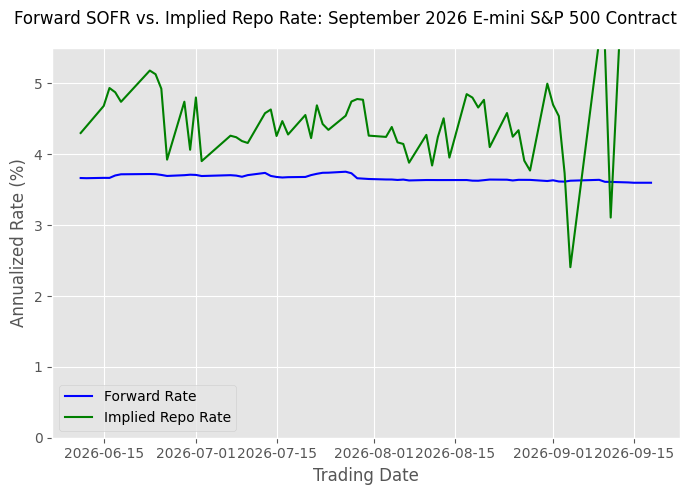

In [ ]:
# 1. Define data to be plotted
plot_data=[market_data['Forward Rate']*100,
           market_data['Implied Repo Rate']*100]

# 2. Define the series
series=['Forward Rate',
        'Implied Repo Rate']

# 3. x_axis dates
x_axis=market_data.index

size=(7,5)
markers=['']*2
colors=['b','g']

# use nanmin and nanmax so that nan is ignogred
y_lower=np.nanmin(plot_data)-1
y_upper=np.nanmax(plot_data)+1


ylim=[0,5.5]
title='Forward SOFR vs. Implied Repo Rate: September 2026 E-mini S&P 500 Contract'
xlabel='Trading Date'
ylabel='Annualized Rate (%)'
fq.one_y_axis(x_axis, plot_data, title=title, series_labels=series, xlabel=xlabel,
              y_limits=ylim,ylabel=ylabel, markers=markers,colors=colors,
              figure_size=size)

## 🚗 The "Express Lane" Effect: Why Arbitrage Bands Expand
Take a look at the graph of our results. Two things should immediately jump out at you:
1. **The Expiration Explosio:** The Expiration Explosion: As the ratio of 360 to days remaining explodes, the green Implied Repo Rate violently whipsaws—plunging to 2.4% before rocketing off the top of the chart. This is the annualization exaggeration in action. As the days to expiration shrink toward zero, any microscopic noise in our dividend estimates or timestamp mismatches is greatly magnified.
2. **Our Assumptions Matter:** More importantly for our underlying mechanics, look at the spread before the September chaos. The green Implied Repo Rate is consistently trading above the blue Forward SOFR baseline. You might be tempted to look at that gap and conclude that a mathematically "risk-free" profit exists, but resist that temptation. At this point, your suspicions should be on high alert. Let's reiterate: a demonstration is not the same thing as a verification. We have made dubious assumptions to accommodate missing data, and those undoubtedly account for some of the noise.

But assumptions notwithstanding, what does an implied rate persistently in excess of SOFR tell us? It tells us the market is forcing a higher financing rate than the risk-free baseline. And that shouldn't surprise us. Arbitrage is easy to describe on paper, but executing it in the real world is a completely different matter. What we call "arbitrage bands" are flexible, bending under the weight of market risk and institutional friction.

To understand why, think about dynamic toll lanes on a modern highway. Imagine an express lane where the toll changes based on traffic density. At 2:00 AM, the highway is empty, and the toll is just \$0.50. But at 5:00 PM on a Friday before a holiday, the highway is jammed. To manage capacity, the system hikes the toll to \$15.00.

In financial markets, the **Prime Brokers' Balance Sheets and the Market to Borrow Stock** are the highway, and **Trades** are the cars.


Hedge funds cannot execute billions of dollars of S&P 500 basis trades without borrowing capital and balance sheet space from a prime broker. And just like the express lane, the bank's capacity isn't infinite—it is constrained by strict capital requirements. When the market gets congested, the prime broker hikes their "toll" to use their balance sheet, widening the arbitrage band.

### 🔄 Two-Way Traffic: The Cost of Borrowing Stocks vs. Cash

But it goes even deeper than dynamic surge pricing. On our financial highway, the toll you pay depends entirely on **which direction you are traveling.** There is no single "interest rate" for arbitrage.

**Direction 1: Cash & Carry (Futures are too expensive)**
If the futures price is trading too high, an arbitrageur will short the futures and buy the underlying cash index.
* **The Toll:** To buy the basket of 500 stocks, you have to borrow money. The interest rate a prime broker charges you to borrow cash against a basket of volatile equities is higher than borrowing against pristine US Treasuries (which is what SOFR tracks) and increases with demand.

**Direction 2: Reverse Cash & Carry (Futures are too cheap)**
If the futures price is trading too low, an arbitrageur will buy the futures and short the underlying cash index.
* **The Toll:** To short the index, you have to borrow the actual shares of all 500 companies. Borrowing stocks isn't free—you have to pay a **stock borrow fee** to the lender. On top of that, you receive cash for selling the shorted stocks, which you then lend out to earn interest (often at a lower rate than you'd prefer).

### 🩸 The Dividend Bleed

These differing rates bleed into our dividend math. Textbooks ofen assume dividends are perfectly reinvested at a single "risk-free rate."

In reality:
* If you are **Long** the stocks (Cash & Carry), you receive the dividends and reinvest them, but usually at a lower lending rate.
* If you are **Short** the stocks (Reverse Cash & Carry), you are liable for the dividends. You have to pay those dividends out of your own pocket to the person you borrowed the shares from, often financing that payment at a higher borrowing rate.

What looks like a juicy, unexploited arbitrage opportunity might actually be a mirage. Once you factor in the prime broker's surge pricing, stock borrow fees, and dividend reinvestment friction, the net profit often drops to zero.

This is why we look at arbitrage as a **dynamic, breathing band** rather than a static line. The width of that band is constantly expanding and contracting based on the real-time density and direction of the financial highway.

---
<details>
<summary><font size="4">🏦 A Brief Detour: What Exactly is a Prime Broker?</b></font></summary>
<blockquote>
What "Balance Sheet Premium" are we talking about?

If you ask most finance students what a broker does, they will usually describe an Executing Broker—the entity that routes your order to an exchange to buy or sell a security. But for hedge funds and large institutional quantitative desks, execution is the easy part. The real bottleneck is financing.

Enter the Prime Broker (usually a massive investment bank like Goldman Sachs, Morgan Stanley, or JPMorgan). A prime broker acts as the central hub for a hedge fund's operations. They are less of an executing middleman and more of a specialized, high-octane bank.

Here is the difference that matters for our math:

* **Executing Broker:** "You want to buy 500 shares of Apple? I will route that to the NASDAQ for you."

* **Prime Broker:** "You want to execute a $500 million Index Arbitrage trade? I will hold your collateral, clear the futures trades, lend you the cash to buy the underlying stocks, and charge you a daily interest rate for using my bank's balance sheet."

Why this matters?:
When a quantitative hedge fund spots a mispricing between the S&P 500 Spot index and the Futures contract, they need lots of leverage to exploit it. They get that cash from their Prime Broker.

The Prime Broker doesn't lend cash at the pure risk-free SOFR rate. They charge SOFR + a spread. That exact spread—the cost of doing business with a Prime Broker.
</blockquote>
</details>

## 🗺️ The Big Picture
In this notebook, we dragged the frictionless textbook cost-of-carry model out into the real world. By aligning spot prices, futures contracts, and time-weighted dividends, we extracted the market's Implied Repo Rate (IRR) and stacked it against Forward SOFR. We didn't do this just to prove an equation—we did it to measure the exact premium prime brokers charge for leverage.

What you should walk away understanding:

* **The map is not the territory:** Textbooks assume arbitrage is free and instantaneous. In reality, prime broker fees, hard-to-borrow stock costs, and dividend liabilities create an unavoidable wedge between what presents on paper and what you can actually execute.

* **Infrastructure breathes:** The boundaries of profitability are built on bank balance sheets, not steel. When market sentiment flips risk-off, borrowing capacity constricts, causing the arbitrage band to dramatically widen right when the theoretical mispricing is largest.

* **Direction dictates the toll:** There is no single, universal "risk-free rate" for a trading desk. Borrowing cash to buy the index (the Cash & Carry toll) incurs completely different structural costs than physically locating and borrowing 500 individual equities to short it (the Reverse Cash & Carry toll).